In [1]:
# =========================================
# 1. IMPORTS
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
# =========================================
# 2. LOAD DATASET
# =========================================

df = pd.read_csv("data/credit_risk_dataset.csv")

print("Shape:", df.shape)
df.head()

Shape: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
# =========================================
# 3. BASIC INFO
# =========================================

print("\nColumn Info:\n")
print(df.info())


Column Info:

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB
None


In [4]:
print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nTarget Distribution:\n")
print(df["loan_status"].value_counts())
print(df["loan_status"].value_counts(normalize=True))


Missing Values:

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Target Distribution:

loan_status
0    25473
1     7108
Name: count, dtype: int64
loan_status
0    0.781836
1    0.218164
Name: proportion, dtype: float64


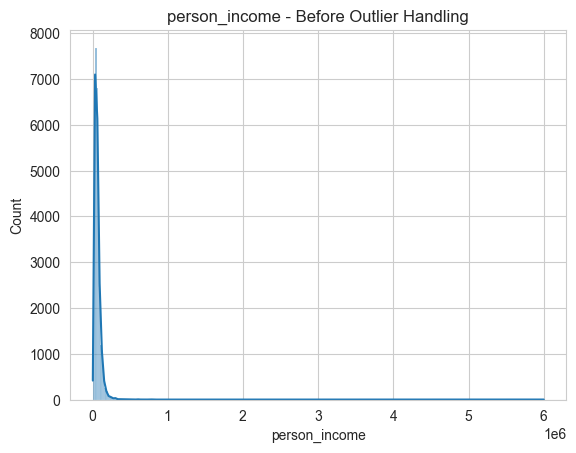

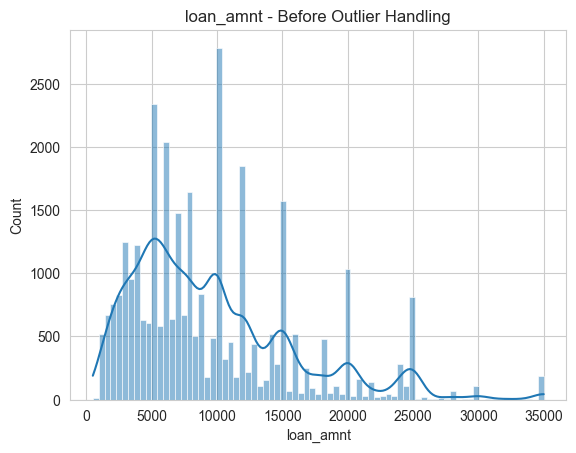

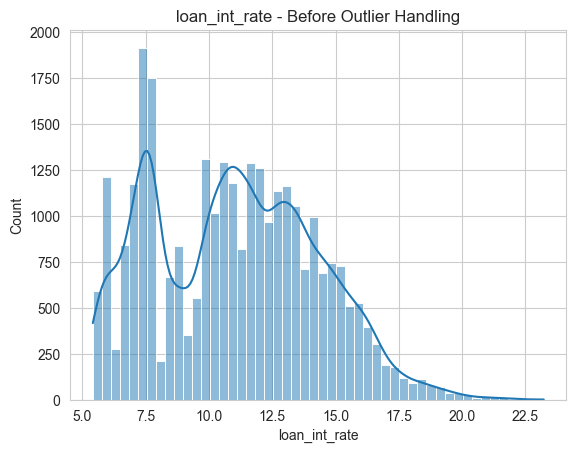

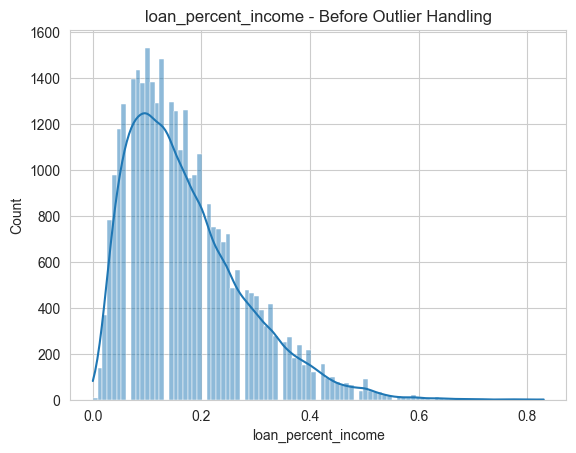

In [5]:
# =========================================
# DISTRIBUTIONS BEFORE OUTLIERS
# =========================================

cols_to_plot = [
    "person_income",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income"
]

for col in cols_to_plot:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} - Before Outlier Handling")
    plt.show()

In [6]:
# =========================================
# OUTLIER HANDLING
# =========================================

def cap_outliers(df, cols, lower_quantile=0.01, upper_quantile=0.99):
    df = df.copy()
    
    for col in cols:
        lower = df[col].quantile(lower_quantile)
        upper = df[col].quantile(upper_quantile)
        
        df[col] = df[col].clip(lower, upper)
        
    return df


# Columns where outliers matter most
outlier_cols = [
    "person_income",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "person_emp_length",
    "cb_person_cred_hist_length"
]

df_clean = cap_outliers(df, outlier_cols)

print("Outlier handling done.")

Outlier handling done.


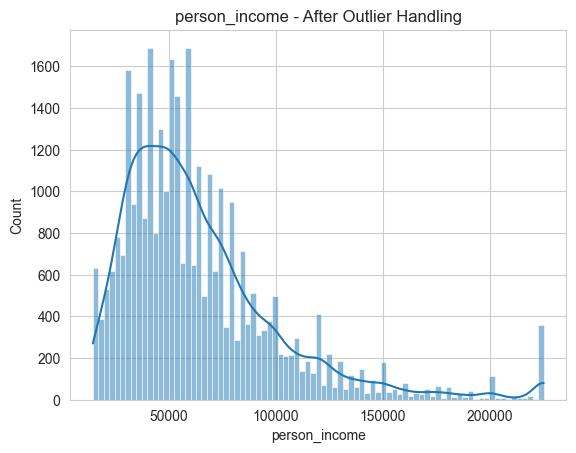

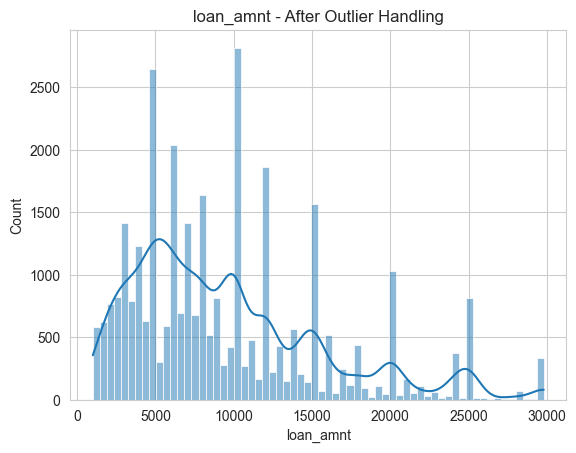

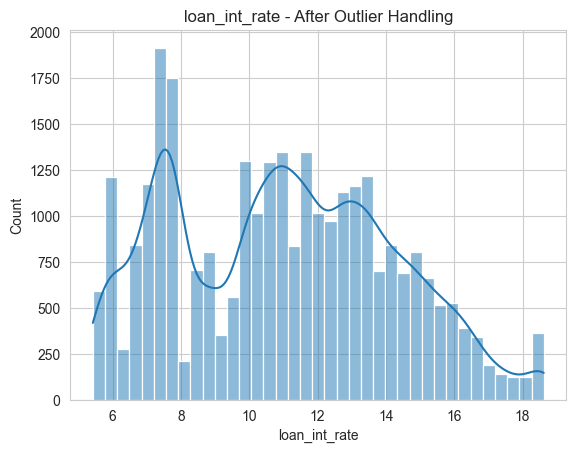

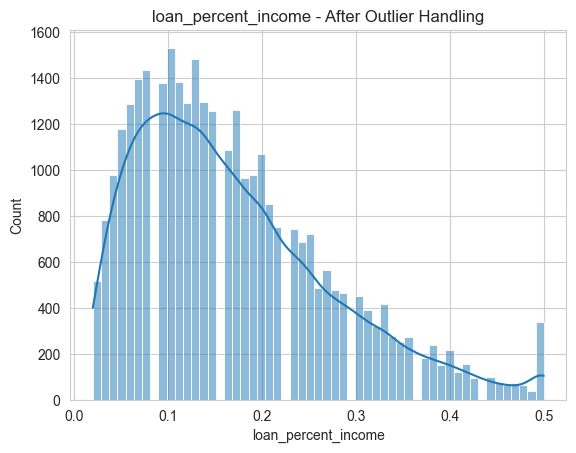

In [7]:
# =========================================
# DISTRIBUTIONS AFTER OUTLIERS
# =========================================

for col in cols_to_plot:
    plt.figure()
    sns.histplot(df_clean[col], kde=True)
    plt.title(f"{col} - After Outlier Handling")
    plt.show()

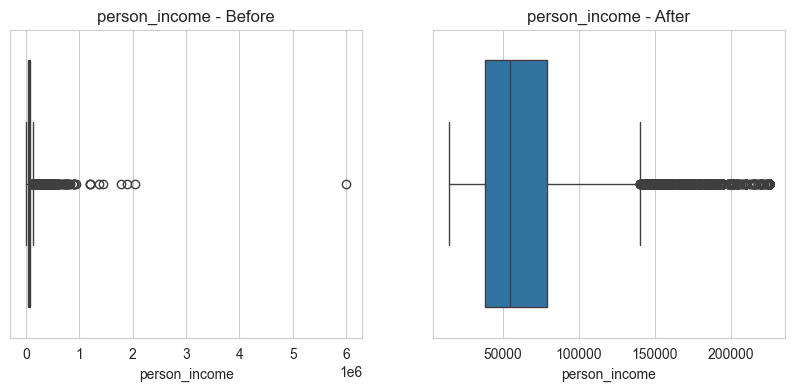

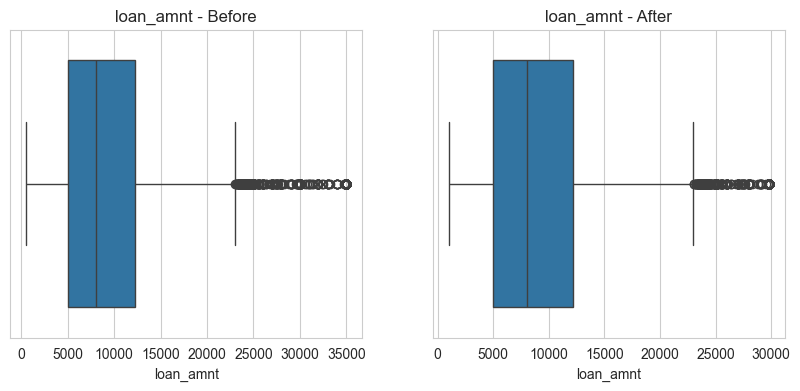

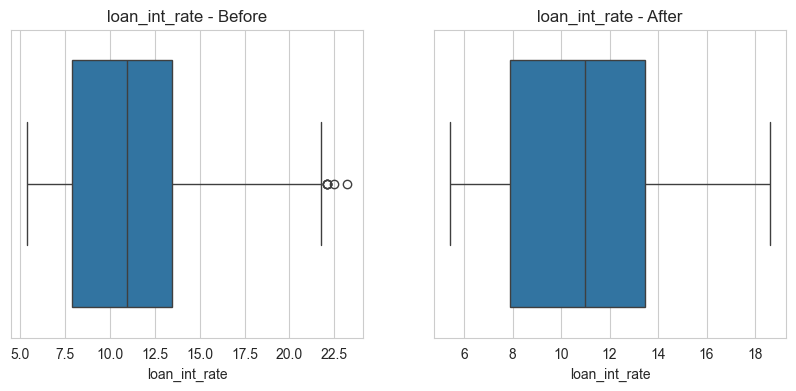

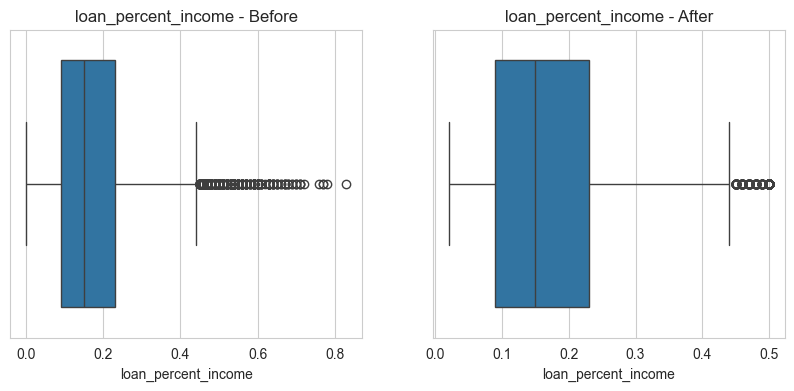

In [8]:
for col in cols_to_plot:
    plt.figure(figsize=(10,4))
    
    plt.subplot(1,2,1)
    sns.boxplot(x=df[col])
    plt.title(f"{col} - Before")
    
    plt.subplot(1,2,2)
    sns.boxplot(x=df_clean[col])
    plt.title(f"{col} - After")
    
    plt.show()

In [9]:
df_clean.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,32581.000000,31686.000000,32581.000000,29465.00000,32581.000000,32581.00000,32581.000000
mean,27.734600,64368.147970,4.758663,9556.484608,11.00234,0.218164,0.16974,5.744514
std,6.348078,37761.494419,3.934398,6202.355384,3.21582,0.413006,0.10482,3.817842
min,20.000000,14400.000000,0.000000,1000.000000,5.42000,0.000000,0.02000,2.000000
25%,23.000000,38500.000000,2.000000,5000.000000,7.90000,0.000000,0.09000,3.000000
50%,26.000000,55000.000000,4.000000,8000.000000,10.99000,0.000000,0.15000,4.000000
75%,30.000000,79200.000000,7.000000,12200.000000,13.47000,0.000000,0.23000,8.000000
max,144.000000,225200.000000,18.000000,29800.000000,18.62000,1.000000,0.50000,17.000000


In [10]:
df = df_clean

In [11]:
# =========================================
# 4. FEATURES & TARGET
# =========================================

X = df.drop("loan_status", axis=1)
y = df["loan_status"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (32581, 11)
y shape: (32581,)


In [12]:
# =========================================
# 5. TRAIN / VAL / TEST SPLIT
# =========================================

from sklearn.model_selection import train_test_split

# First split: train vs temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Split temp into validation + test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nTrain distribution:\n", y_train.value_counts(normalize=True))
print("\nValidation distribution:\n", y_val.value_counts(normalize=True))
print("\nTest distribution:\n", y_test.value_counts(normalize=True))

Train: (22806, 11)
Validation: (4887, 11)
Test: (4888, 11)

Train distribution:
 loan_status
0    0.781856
1    0.218144
Name: proportion, dtype: float64

Validation distribution:
 loan_status
0    0.78187
1    0.21813
Name: proportion, dtype: float64

Test distribution:
 loan_status
0    0.78171
1    0.21829
Name: proportion, dtype: float64


In [13]:
# =========================================
# 6. PREPROCESSING PIPELINE
# =========================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file"
]

numerical_features = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"
]

# Numeric pipeline
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Preprocessing pipeline ready.")

Preprocessing pipeline ready.


In [14]:
# ==============================
# EXPERIMENT 1: MODEL COMPARISON
# ==============================

In [15]:
# =========================================
# 7. MODEL DEFINITIONS
# =========================================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier

def get_models(preprocessor):
    models = {
        "Logistic Regression": Pipeline([
            ("preprocessor", preprocessor),
            ("classifier", LogisticRegression(max_iter=1000, random_state=42))
        ]),

        "SVM": Pipeline([
            ("preprocessor", preprocessor),
            ("classifier", SVC(probability=True, random_state=42))
        ]),
        
        "Decision Tree": Pipeline([
            ("preprocessor", preprocessor),
            ("classifier", DecisionTreeClassifier(random_state=42))
        ]),
        
        "Random Forest": Pipeline([
            ("preprocessor", preprocessor),
            ("classifier", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
        ]),
        
        "XGBoost": Pipeline([
            ("preprocessor", preprocessor),
            ("classifier", XGBClassifier(
                n_estimators=200,
                max_depth=6,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric="logloss",
                random_state=42
            ))
        ]),
        
        "LightGBM": Pipeline([
            ("preprocessor", preprocessor),
            ("classifier", LGBMClassifier(
                n_estimators=200,
                learning_rate=0.1,
                random_state=42
            ))
        ]),
        
        "Neural Network": Pipeline([
            ("preprocessor", preprocessor),
            ("classifier", MLPClassifier(
                hidden_layer_sizes=(64, 32),
                max_iter=300,
                random_state=42
            ))
        ])
    }
    
    return models

In [16]:
# =========================================
# CROSS-VALIDATION (DETAILED)
# =========================================

from sklearn.model_selection import cross_validate, StratifiedKFold

def cross_validate_detailed(model, X, y, cv=5):
    scoring = {
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc"
    }

    cv_strategy = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv_strategy,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    return scores

In [18]:
# =========================================
# 9. RUN CROSS-VALIDATION
# =========================================

models = get_models(preprocessor)

all_fold_results = {}

for name, model in models.items():
    print(f"\nRunning CV for {name}...")
    
    scores = cross_validate_detailed(model, X_train, y_train)
    
    fold_df = pd.DataFrame({
        "Fold": range(1, 6),
        "Accuracy": scores["test_accuracy"],
        "Precision": scores["test_precision"],
        "Recall": scores["test_recall"],
        "F1": scores["test_f1"],
        "ROC-AUC": scores["test_roc_auc"]
    })
    
    all_fold_results[name] = fold_df


Running CV for Logistic Regression...



Running CV for SVM...

Running CV for Decision Tree...

Running CV for Random Forest...

Running CV for XGBoost...

Running CV for LightGBM...
[LightGBM] [Info] Number of positive: 3980, number of negative: 14265
[LightGBM] [Info] Number of positive: 3980, number of negative: 14265
[LightGBM] [Info] Number of positive: 3980, number of negative: 14265
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001052 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000998 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 887
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001007 seconds.
You can set `force_row_wise=true` to remove the overhead.

/Users/archith25/Developer/My_Workspace/Explainable_Credit_Risk_Prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/archith25/Developer/My_Workspace/Explainable_Credit_Risk_Prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/archith25/Developer/My_Workspace/Explainable_Credit_Risk_Prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/archith25/Developer/My_Workspace/Explainable_Credit_Risk_Prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fit


Running CV for Neural Network...


/Users/archith25/Developer/My_Workspace/Explainable_Credit_Risk_Prediction/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/archith25/Developer/My_Workspace/Explainable_Credit_Risk_Prediction/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/archith25/Developer/My_Workspace/Explainable_Credit_Risk_Prediction/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


In [19]:
# =========================================
# COMBINED FOLD RESULTS (ALL MODELS)
# =========================================

combined_folds_df = []

for model_name, df_fold in all_fold_results.items():
    temp_df = df_fold.copy()
    temp_df["Model"] = model_name
    combined_folds_df.append(temp_df)

combined_folds_df = pd.concat(combined_folds_df, ignore_index=True)

# Reorder columns nicely
combined_folds_df = combined_folds_df[
    ["Model", "Fold", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
]

combined_folds_df

,Model,Fold,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,1,0.864095,0.772926,0.533668,0.631391,0.862817
1,Logistic Regression,2,0.869985,0.783898,0.557789,0.651791,0.874838
2,Logistic Regression,3,0.871300,0.770557,0.583920,0.664380,0.870194
3,Logistic Regression,4,0.859899,0.741848,0.548744,0.630849,0.865587
4,Logistic Regression,5,0.863407,0.750000,0.560804,0.641748,0.866023
5,SVM,1,0.911004,0.928675,0.641206,0.758621,0.893628
6,SVM,2,0.915369,0.933144,0.659296,0.772674,0.896383
7,SVM,3,0.914273,0.937681,0.650251,0.767953,0.902040
8,SVM,4,0.909669,0.938346,0.627136,0.751807,0.897485
9,SVM,5,0.911423,0.920341,0.650251,0.762073,0.898450


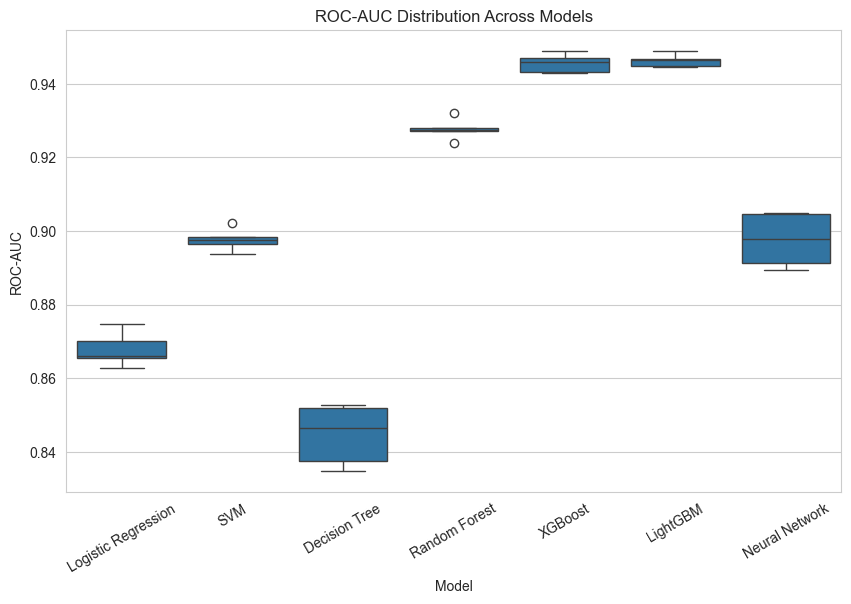

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(data=combined_folds_df, x="Model", y="ROC-AUC")
plt.xticks(rotation=30)
plt.title("ROC-AUC Distribution Across Models")
plt.show()

In [21]:
summary_stats = []

for name, df_fold in all_fold_results.items():
    summary_stats.append({
        "Model": name,
        "Mean ROC-AUC": df_fold["ROC-AUC"].mean(),
        "Std ROC-AUC": df_fold["ROC-AUC"].std(),
        "Mean Recall": df_fold["Recall"].mean(),
        "Std Recall": df_fold["Recall"].std()
    })

summary_df = pd.DataFrame(summary_stats)
summary_df = summary_df.sort_values(by="Mean ROC-AUC", ascending=False).reset_index(drop=True)
summary_df["CV% (AUC)"] = (summary_df["Std ROC-AUC"] / summary_df["Mean ROC-AUC"]) * 100

summary_df

,Model,Mean ROC-AUC,Std ROC-AUC,Mean Recall,Std Recall,CV% (AUC)
0,LightGBM,0.946312,0.001724,0.725226,0.007474,0.182207
1,XGBoost,0.945570,0.002523,0.729246,0.007092,0.266827
2,Random Forest,0.927702,0.002941,0.714573,0.008468,0.317056
3,SVM,0.897597,0.003070,0.645628,0.012156,0.342079
4,Neural Network,0.897566,0.007193,0.713166,0.018403,0.801377
5,Logistic Regression,0.867892,0.004693,0.556985,0.018387,0.540743
6,Decision Tree,0.844697,0.008211,0.767236,0.015052,0.972018


In [22]:
# Example Standard Deviation Calculation for XGBoost

print("STD DEV (XGBoost):")
print("Accuracy:", np.std(scores["test_accuracy"]))
print("Precision:", np.std(scores["test_precision"]))
print("Recall:", np.std(scores["test_recall"]))
print("F1:", np.std(scores["test_f1"]))
print("ROC-AUC:", np.std(scores["test_roc_auc"]))

STD DEV (XGBoost):
Accuracy: 0.00532158028471733
Precision: 0.02126752598752514
Recall: 0.0164603357488026
F1: 0.01289053855361248
ROC-AUC: 0.006433515890177539


In [23]:
# =========================================
# 10. FINAL TEST EVALUATION
# =========================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

test_results = []

for name, model in models.items():
    print(f"Training {name} on full training data...")
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    test_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

test_results_df = pd.DataFrame(test_results)
test_results_df = test_results_df.sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)

test_results_df

Training Logistic Regression on full training data...
Training SVM on full training data...
Training Decision Tree on full training data...
Training Random Forest on full training data...
Training XGBoost on full training data...
Training LightGBM on full training data...
[LightGBM] [Info] Number of positive: 4975, number of negative: 17831
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000609 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 894
[LightGBM] [Info] Number of data points in the train set: 22806, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.218144 -> initscore=-1.276513
[LightGBM] [Info] Start training from score -1.276513


/Users/archith25/Developer/My_Workspace/Explainable_Credit_Risk_Prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/archith25/Developer/My_Workspace/Explainable_Credit_Risk_Prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training Neural Network on full training data...


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,LightGBM,0.939034,0.976456,0.738519,0.840982,0.954295
1,XGBoost,0.936375,0.965517,0.734770,0.834486,0.950949
2,Random Forest,0.934943,0.965217,0.728210,0.830128,0.929094
3,Neural Network,0.919804,0.891986,0.719775,0.796680,0.909728
4,SVM,0.912643,0.918848,0.657919,0.766794,0.900266
5,Logistic Regression,0.868658,0.767296,0.571696,0.655209,0.870815
6,Decision Tree,0.892594,0.738556,0.786317,0.761689,0.854294
